 # Описание проекта: промышленность

### Цель проекта

Чтобы оптимизировать производственные расходы, металлургический комбинат ООО «Так закаляем сталь» решил уменьшить потребление электроэнергии на этапе обработки стали. **Вам предстоит построить модель, которая предскажет температуру стали.**

### Описание этапа обработки

Сталь обрабатывают в металлическом ковше вместимостью около 100 тонн. Чтобы ковш выдерживал высокие температуры, изнутри его облицовывают огнеупорным кирпичом. Расплавленную сталь заливают в ковш и подогревают до нужной температуры графитовыми электродами. Они установлены в крышке ковша. 

Из сплава выводится сера (десульфурация), добавлением примесей корректируется химический состав и отбираются пробы. Сталь легируют — изменяют её состав — подавая куски сплава из бункера для сыпучих материалов или проволоку через специальный трайб-аппарат (англ. tribe, «масса»).

Перед тем как первый раз ввести легирующие добавки, измеряют температуру стали и производят её химический анализ. Потом температуру на несколько минут повышают, добавляют легирующие материалы и продувают сплав инертным газом. Затем его перемешивают и снова проводят измерения. Такой цикл повторяется до достижения целевого химического состава и оптимальной температуры плавки.

Тогда расплавленная сталь отправляется на доводку металла или поступает в машину непрерывной разливки. Оттуда готовый продукт выходит в виде заготовок-слябов (англ. slab, «плита»).

### Описание данных

Данные состоят из файлов, полученных из разных источников:

```data_arc_new.csv'```   — данные об электродах;

```data_bulk_new.csv``` — данные о подаче сыпучих материалов (объём);

```data_bulk_time_new.csv``` — данные о подаче сыпучих материалов (время);

```data_gas_new.csv``` — данные о продувке сплава газом;

```data_temp_new.csv``` — результаты измерения температуры;

```data_wire_new.csv``` — данные о проволочных материалах (объём);

```data_wire_time_new.csv``` — данные о проволочных материалах (время).

Во всех файлах столбец ```key``` содержит номер партии. В файлах может быть несколько строк с одинаковым значением ```key```: они соответствуют разным итерациям обработки.

1-я часть - Вступление (название, описание, цель проекта). Исследовательский анализ данных ДО объединения таблиц в одну. Составления плана дальнейшей работы. Уточнение задачи (вопросы).


2-я часть - Предобработка, объединение таблиц в общий датафрейм и его анализ. В этой же части идёт машинное обучение: построение моделей, тестирование одной лучшей модели. Итоговый вывод


3-я часть -  Отчет

In [1]:
random_state  = 310723;

**Результат**

| Плохо, на доработку | MAE > 6.8 |

| Нормально | 6.3 < MAE ≤ 6.8 |

| Хорошо | 6.0 < MAE ≤ 6.3 |

| Отлично | MAE ≤ 6.0 |


# Проект

## 1-часть проекта. Исследовательский анализ данных

In [2]:
#библиотеки, что понадобятся в первой части проекта
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import time

import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

In [3]:
#библиотеки из второй части
import random

import sklearn
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from catboost import CatBoostRegressor
from lightgbm import LGBMRegressor

from sklearn.model_selection import GridSearchCV, train_test_split, cross_val_score
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.preprocessing import StandardScaler
from sklearn.dummy import DummyRegressor
from sklearn.metrics import make_scorer



In [4]:
try:
    data_arc_new = pd.read_csv('/datasets/data_arc_new.csv')
    data_bulk_new=pd.read_csv( '/datasets/data_bulk_new.csv')
    data_bulk_time_new=pd.read_csv( '/datasets/data_bulk_time_new.csv')
    data_gas_new=pd.read_csv( '/datasets/data_gas_new.csv')
    data_temp_new=pd.read_csv( '/datasets/data_temp_new.csv')
    data_wire_new=pd.read_csv( '/datasets/data_wire_new.csv')
    data_wire_time_new=pd.read_csv( '/datasets/data_wire_time_new.csv')
except:
    data_arc_new = pd.read_csv( 'E:\проект\data_arc_new.csv')
    data_bulk_new=pd.read_csv( 'E:\проект\data_bulk_new.csv')
    data_bulk_time_new=pd.read_csv( 'E:\проект\data_bulk_time_new.csv')
    data_gas_new=pd.read_csv( 'E:\проект\data_gas_new.csv')
    data_temp_new=pd.read_csv( 'E:\проект\data_temp_new.csv')
    data_wire_new=pd.read_csv( 'E:\проект\data_wire_new.csv')
    data_wire_time_new=pd.read_csv( 'E:\проект\data_wire_time_new.csv')

### Данные об электродах (data_arc_new)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14876 entries, 0 to 14875
Data columns (total 5 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   key                   14876 non-null  int64  
 1   Начало нагрева дугой  14876 non-null  object 
 2   Конец нагрева дугой   14876 non-null  object 
 3   Активная мощность     14876 non-null  float64
 4   Реактивная мощность   14876 non-null  float64
dtypes: float64(2), int64(1), object(2)
memory usage: 581.2+ KB


array([[<AxesSubplot:title={'center':'key'}>,
        <AxesSubplot:title={'center':'Активная мощность'}>],
       [<AxesSubplot:title={'center':'Реактивная мощность'}>,
        <AxesSubplot:>]], dtype=object)

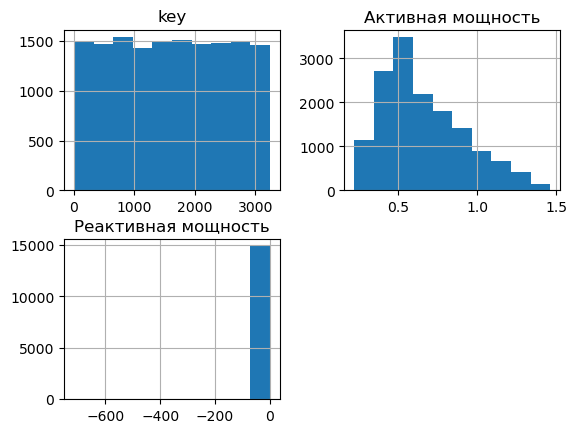

In [5]:
data_arc_new.info()
data_arc_new.hist()

In [6]:
data_arc_new.head()

,key,Начало нагрева дугой,Конец нагрева дугой,Активная мощность,Реактивная мощность
0,1,2019-05-03 11:02:14,2019-05-03 11:06:02,0.305130,0.211253
1,1,2019-05-03 11:07:28,2019-05-03 11:10:33,0.765658,0.477438
2,1,2019-05-03 11:11:44,2019-05-03 11:14:36,0.580313,0.430460
3,1,2019-05-03 11:18:14,2019-05-03 11:24:19,0.518496,0.379979
4,1,2019-05-03 11:26:09,2019-05-03 11:28:37,0.867133,0.643691


In [7]:
#распределние признаков
data_arc_new.describe()

,key,Активная мощность,Реактивная мощность
count,14876.000000,14876.000000,14876.000000
mean,1615.220422,0.662752,0.438986
std,934.571502,0.258885,5.873485
min,1.000000,0.223120,-715.479924
25%,806.000000,0.467115,0.337175
50%,1617.000000,0.599587,0.441639
75%,2429.000000,0.830070,0.608201
max,3241.000000,1.463773,1.270284


**Аномалия**. Минимальное значение реактивной мощности показывает -715, что  в прниципе невозможно

In [8]:
#поиск пропущенных значений
data_arc_new.isna().sum()

key                     0
Начало нагрева дугой    0
Конец нагрева дугой     0
Активная мощность       0
Реактивная мощность     0
dtype: int64

In [9]:
data_arc_new.duplicated().sum()

0

**промежуточный вывод**

В датасете data_arc_new у нас нет пропусков. Есть одна аномалия в минимальной значении реактивной мощности. По графику распределние мощности выглядит в полне нормально.

###  Данные о подаче сыпучих материалов (объём) (data_bulk_new)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3129 entries, 0 to 3128
Data columns (total 16 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   key      3129 non-null   int64  
 1   Bulk 1   252 non-null    float64
 2   Bulk 2   22 non-null     float64
 3   Bulk 3   1298 non-null   float64
 4   Bulk 4   1014 non-null   float64
 5   Bulk 5   77 non-null     float64
 6   Bulk 6   576 non-null    float64
 7   Bulk 7   25 non-null     float64
 8   Bulk 8   1 non-null      float64
 9   Bulk 9   19 non-null     float64
 10  Bulk 10  176 non-null    float64
 11  Bulk 11  177 non-null    float64
 12  Bulk 12  2450 non-null   float64
 13  Bulk 13  18 non-null     float64
 14  Bulk 14  2806 non-null   float64
 15  Bulk 15  2248 non-null   float64
dtypes: float64(15), int64(1)
memory usage: 391.2 KB


array([[<AxesSubplot:title={'center':'key'}>,
        <AxesSubplot:title={'center':'Bulk 1'}>,
        <AxesSubplot:title={'center':'Bulk 2'}>,
        <AxesSubplot:title={'center':'Bulk 3'}>],
       [<AxesSubplot:title={'center':'Bulk 4'}>,
        <AxesSubplot:title={'center':'Bulk 5'}>,
        <AxesSubplot:title={'center':'Bulk 6'}>,
        <AxesSubplot:title={'center':'Bulk 7'}>],
       [<AxesSubplot:title={'center':'Bulk 8'}>,
        <AxesSubplot:title={'center':'Bulk 9'}>,
        <AxesSubplot:title={'center':'Bulk 10'}>,
        <AxesSubplot:title={'center':'Bulk 11'}>],
       [<AxesSubplot:title={'center':'Bulk 12'}>,
        <AxesSubplot:title={'center':'Bulk 13'}>,
        <AxesSubplot:title={'center':'Bulk 14'}>,
        <AxesSubplot:title={'center':'Bulk 15'}>]], dtype=object)

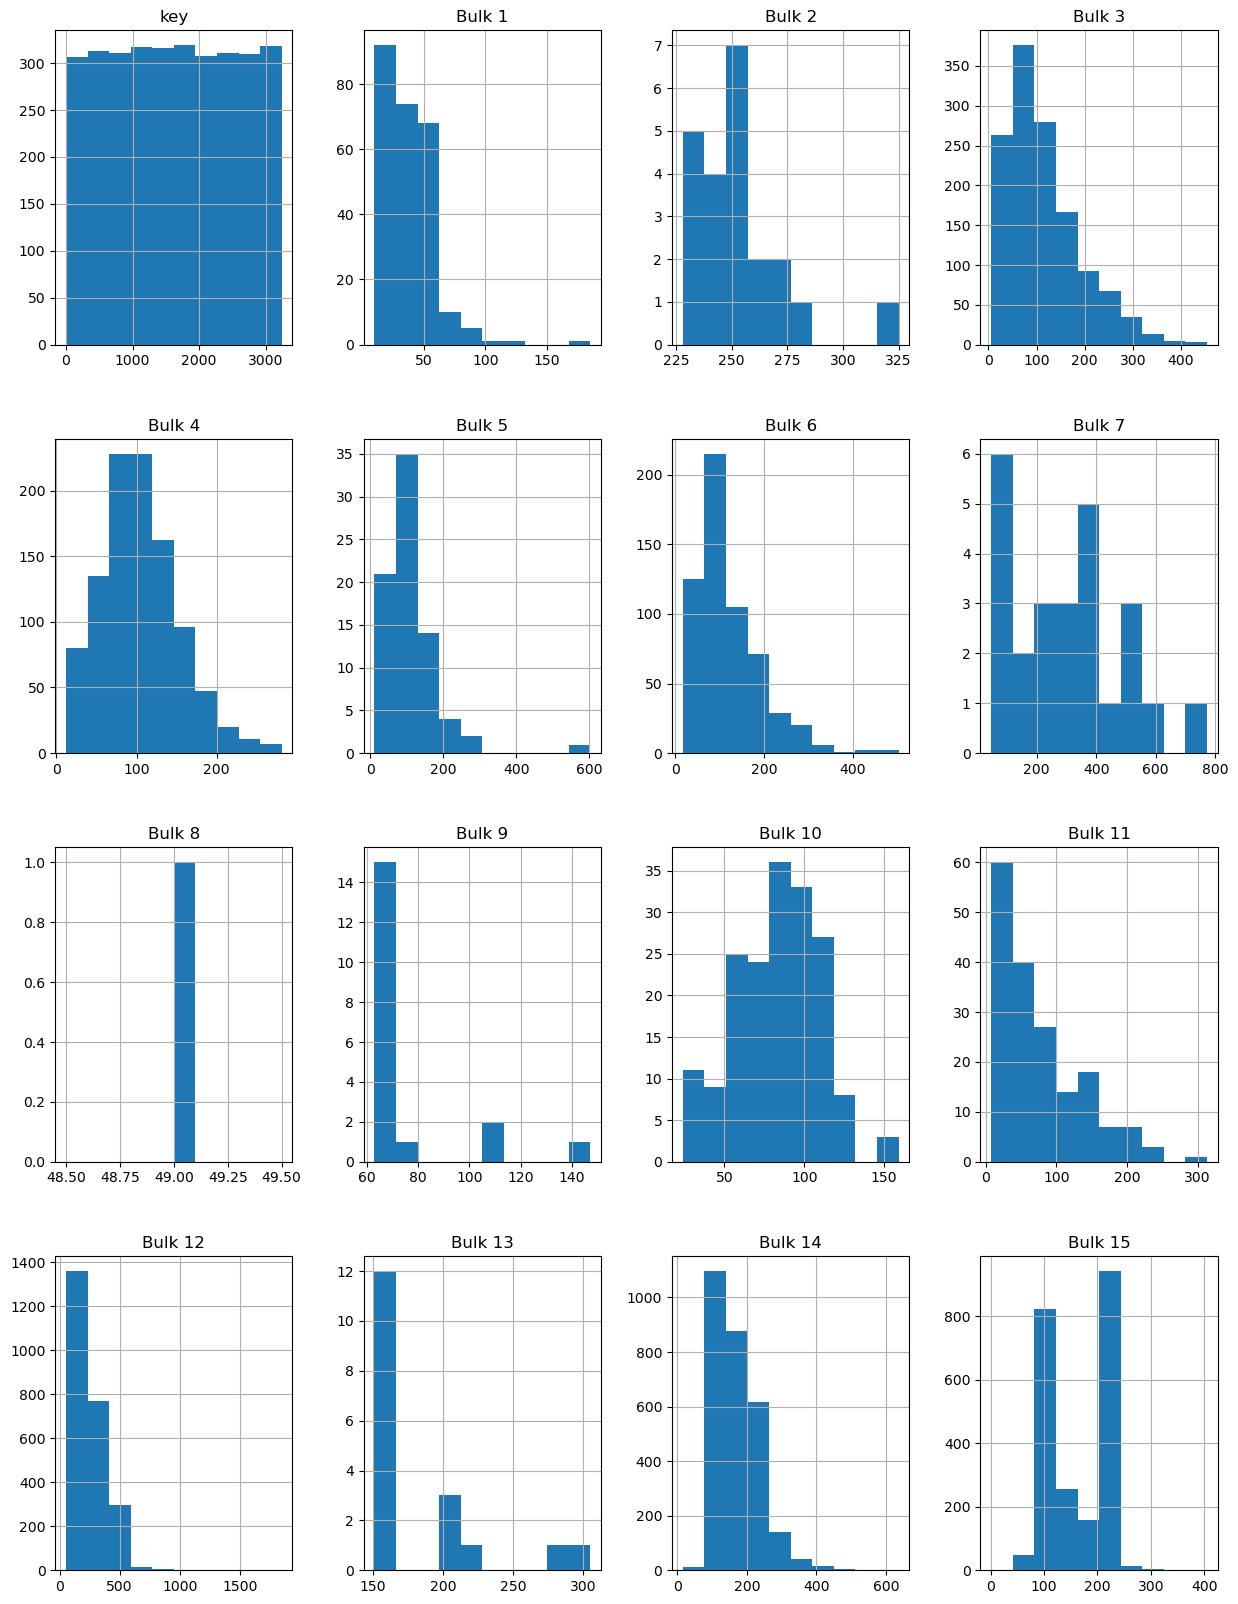

In [10]:
data_bulk_new.info()
data_bulk_new.hist(figsize=(15, 20))

In [11]:
data_bulk_new.head()

,key,Bulk 1,Bulk 2,Bulk 3,Bulk 4,Bulk 5,Bulk 6,Bulk 7,Bulk 8,Bulk 9,Bulk 10,Bulk 11,Bulk 12,Bulk 13,Bulk 14,Bulk 15
0,1,NaN,NaN,NaN,43.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,206.0,NaN,150.0,154.0
1,2,NaN,NaN,NaN,73.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,206.0,NaN,149.0,154.0
2,3,NaN,NaN,NaN,34.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,205.0,NaN,152.0,153.0
3,4,NaN,NaN,NaN,81.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,207.0,NaN,153.0,154.0
4,5,NaN,NaN,NaN,78.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,203.0,NaN,151.0,152.0


In [12]:
data_bulk_new.describe()

,key,Bulk 1,Bulk 2,Bulk 3,Bulk 4,Bulk 5,Bulk 6,Bulk 7,Bulk 8,Bulk 9,Bulk 10,Bulk 11,Bulk 12,Bulk 13,Bulk 14,Bulk 15
count,3129.000000,252.000000,22.000000,1298.000000,1014.000000,77.000000,576.000000,25.000000,1.0,19.000000,176.000000,177.000000,2450.000000,18.000000,2806.000000,2248.000000
mean,1624.383509,39.242063,253.045455,113.879045,104.394477,107.025974,118.925347,305.600000,49.0,76.315789,83.284091,76.819209,260.471020,181.111111,170.284747,160.513345
std,933.337642,18.277654,21.180578,75.483494,48.184126,81.790646,72.057776,191.022904,NaN,21.720581,26.060347,59.655365,120.649269,46.088009,65.868652,51.765319
min,1.000000,10.000000,228.000000,6.000000,12.000000,11.000000,17.000000,47.000000,49.0,63.000000,24.000000,8.000000,53.000000,151.000000,16.000000,1.000000
25%,816.000000,27.000000,242.000000,58.000000,72.000000,70.000000,69.750000,155.000000,49.0,66.000000,64.000000,25.000000,204.000000,153.250000,119.000000,105.000000
50%,1622.000000,31.000000,251.500000,97.500000,102.000000,86.000000,100.000000,298.000000,49.0,68.000000,86.500000,64.000000,208.000000,155.500000,151.000000,160.000000
75%,2431.000000,46.000000,257.750000,152.000000,133.000000,132.000000,157.000000,406.000000,49.0,70.500000,102.000000,106.000000,316.000000,203.500000,205.750000,205.000000
max,3241.000000,185.000000,325.000000,454.000000,281.000000,603.000000,503.000000,772.000000,49.0,147.000000,159.000000,313.000000,1849.000000,305.000000,636.000000,405.000000


In [13]:
data_bulk_new.isna().sum()

key           0
Bulk 1     2877
Bulk 2     3107
Bulk 3     1831
Bulk 4     2115
Bulk 5     3052
Bulk 6     2553
Bulk 7     3104
Bulk 8     3128
Bulk 9     3110
Bulk 10    2953
Bulk 11    2952
Bulk 12     679
Bulk 13    3111
Bulk 14     323
Bulk 15     881
dtype: int64

In [14]:
data_bulk_new.duplicated().sum()

0

**Промежуточный вывод** 

В данном датасете огромное количество пропусков  и из-за этого очень трудно делать заключителньый анализ о данных по подаче сыпучих. Дубликатов нет

### Данные о подаче сыпучих материалов (время) (data_bulk_time_new)

In [15]:
data_bulk_time_new.info()
#data_bulk_time_new.hist()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3129 entries, 0 to 3128
Data columns (total 16 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   key      3129 non-null   int64 
 1   Bulk 1   252 non-null    object
 2   Bulk 2   22 non-null     object
 3   Bulk 3   1298 non-null   object
 4   Bulk 4   1014 non-null   object
 5   Bulk 5   77 non-null     object
 6   Bulk 6   576 non-null    object
 7   Bulk 7   25 non-null     object
 8   Bulk 8   1 non-null      object
 9   Bulk 9   19 non-null     object
 10  Bulk 10  176 non-null    object
 11  Bulk 11  177 non-null    object
 12  Bulk 12  2450 non-null   object
 13  Bulk 13  18 non-null     object
 14  Bulk 14  2806 non-null   object
 15  Bulk 15  2248 non-null   object
dtypes: int64(1), object(15)
memory usage: 391.2+ KB


In [16]:
data_bulk_time_new.head()

,key,Bulk 1,Bulk 2,Bulk 3,Bulk 4,Bulk 5,Bulk 6,Bulk 7,Bulk 8,Bulk 9,Bulk 10,Bulk 11,Bulk 12,Bulk 13,Bulk 14,Bulk 15
0,1,NaN,NaN,NaN,2019-05-03 11:28:48,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2019-05-03 11:24:31,NaN,2019-05-03 11:14:50,2019-05-03 11:10:43
1,2,NaN,NaN,NaN,2019-05-03 11:36:50,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2019-05-03 11:53:30,NaN,2019-05-03 11:48:37,2019-05-03 11:44:39
2,3,NaN,NaN,NaN,2019-05-03 12:32:39,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2019-05-03 12:27:13,NaN,2019-05-03 12:21:01,2019-05-03 12:16:16
3,4,NaN,NaN,NaN,2019-05-03 12:43:22,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2019-05-03 12:58:00,NaN,2019-05-03 12:51:11,2019-05-03 12:46:36
4,5,NaN,NaN,NaN,2019-05-03 13:30:47,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2019-05-03 13:30:47,NaN,2019-05-03 13:34:12,2019-05-03 13:30:47


In [17]:
data_bulk_time_new.describe()

,key
count,3129.000000
mean,1624.383509
std,933.337642
min,1.000000
25%,816.000000
50%,1622.000000
75%,2431.000000
max,3241.000000


In [18]:
data_bulk_time_new.isna().sum()

key           0
Bulk 1     2877
Bulk 2     3107
Bulk 3     1831
Bulk 4     2115
Bulk 5     3052
Bulk 6     2553
Bulk 7     3104
Bulk 8     3128
Bulk 9     3110
Bulk 10    2953
Bulk 11    2952
Bulk 12     679
Bulk 13    3111
Bulk 14     323
Bulk 15     881
dtype: int64

In [19]:
data_bulk_time_new.duplicated().sum()

0

**Промежуточный вывод**

Здесь также большое количество пропусков. Нужно будет менять формат на  datetime. Дубликатов нет

### Данные о продувке сплава газом (data_gas_new)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3239 entries, 0 to 3238
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   key     3239 non-null   int64  
 1   Газ 1   3239 non-null   float64
dtypes: float64(1), int64(1)
memory usage: 50.7 KB


array([[<AxesSubplot:title={'center':'key'}>,
        <AxesSubplot:title={'center':'Газ 1'}>]], dtype=object)

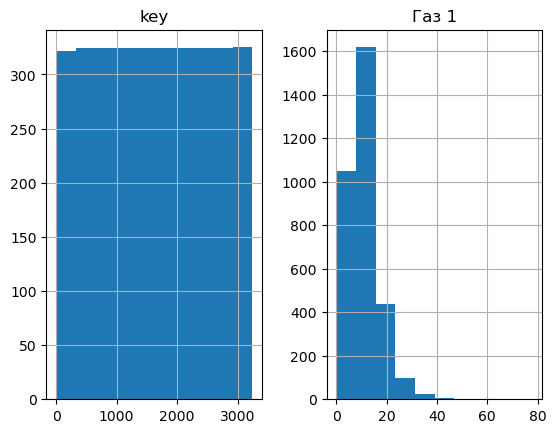

In [20]:
data_gas_new.info()
data_gas_new.hist()

In [21]:
data_gas_new.head()

,key,Газ 1
0,1,29.749986
1,2,12.555561
2,3,28.554793
3,4,18.841219
4,5,5.413692


In [22]:
data_gas_new.describe()

,key,Газ 1
count,3239.000000,3239.000000
mean,1621.861377,11.002062
std,935.386334,6.220327
min,1.000000,0.008399
25%,812.500000,7.043089
50%,1622.000000,9.836267
75%,2431.500000,13.769915
max,3241.000000,77.995040


In [23]:
data_gas_new.isna().sum()

key      0
Газ 1    0
dtype: int64

In [24]:
data_gas_new.duplicated().sum()

0

### Результаты измерения температуры (data_temp_new)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18092 entries, 0 to 18091
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   key           18092 non-null  int64  
 1   Время замера  18092 non-null  object 
 2   Температура   14665 non-null  float64
dtypes: float64(1), int64(1), object(1)
memory usage: 424.2+ KB


array([[<AxesSubplot:title={'center':'key'}>,
        <AxesSubplot:title={'center':'Температура'}>]], dtype=object)

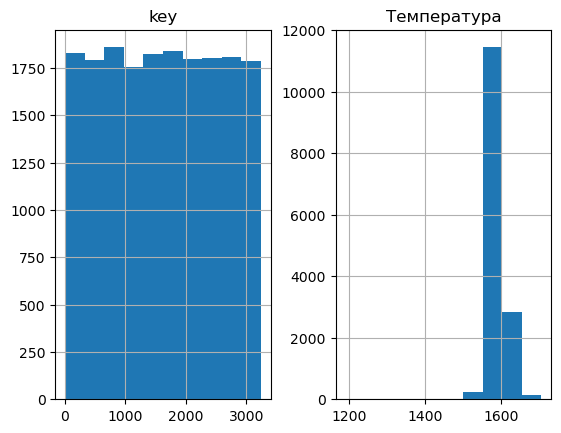

In [25]:
data_temp_new.info()
data_temp_new.hist()

In [26]:
data_temp_new.head()

,key,Время замера,Температура
0,1,2019-05-03 11:02:04,1571.0
1,1,2019-05-03 11:07:18,1604.0
2,1,2019-05-03 11:11:34,1618.0
3,1,2019-05-03 11:18:04,1601.0
4,1,2019-05-03 11:25:59,1606.0


In [27]:
data_temp_new.describe()

,key,Температура
count,18092.000000,14665.000000
mean,1616.460977,1590.722741
std,934.641385,20.394381
min,1.000000,1191.000000
25%,807.750000,1580.000000
50%,1618.000000,1590.000000
75%,2429.000000,1599.000000
max,3241.000000,1705.000000


In [28]:
data_temp_new.isna().sum()

key                0
Время замера       0
Температура     3427
dtype: int64

In [29]:
data_temp_new.duplicated().sum()

0

**Промежуточный вывод**

Пропусков присутствуют только в колонке "Температура". Время нужно будет перевести в datetime. По графику, похоже, присутствует выброс

### Данные о проволочных материалах (объём) (data_wire_new)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3081 entries, 0 to 3080
Data columns (total 10 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   key     3081 non-null   int64  
 1   Wire 1  3055 non-null   float64
 2   Wire 2  1079 non-null   float64
 3   Wire 3  63 non-null     float64
 4   Wire 4  14 non-null     float64
 5   Wire 5  1 non-null      float64
 6   Wire 6  73 non-null     float64
 7   Wire 7  11 non-null     float64
 8   Wire 8  19 non-null     float64
 9   Wire 9  29 non-null     float64
dtypes: float64(9), int64(1)
memory usage: 240.8 KB


array([[<AxesSubplot:title={'center':'key'}>,
        <AxesSubplot:title={'center':'Wire 1'}>,
        <AxesSubplot:title={'center':'Wire 2'}>],
       [<AxesSubplot:title={'center':'Wire 3'}>,
        <AxesSubplot:title={'center':'Wire 4'}>,
        <AxesSubplot:title={'center':'Wire 5'}>],
       [<AxesSubplot:title={'center':'Wire 6'}>,
        <AxesSubplot:title={'center':'Wire 7'}>,
        <AxesSubplot:title={'center':'Wire 8'}>],
       [<AxesSubplot:title={'center':'Wire 9'}>, <AxesSubplot:>,
        <AxesSubplot:>]], dtype=object)

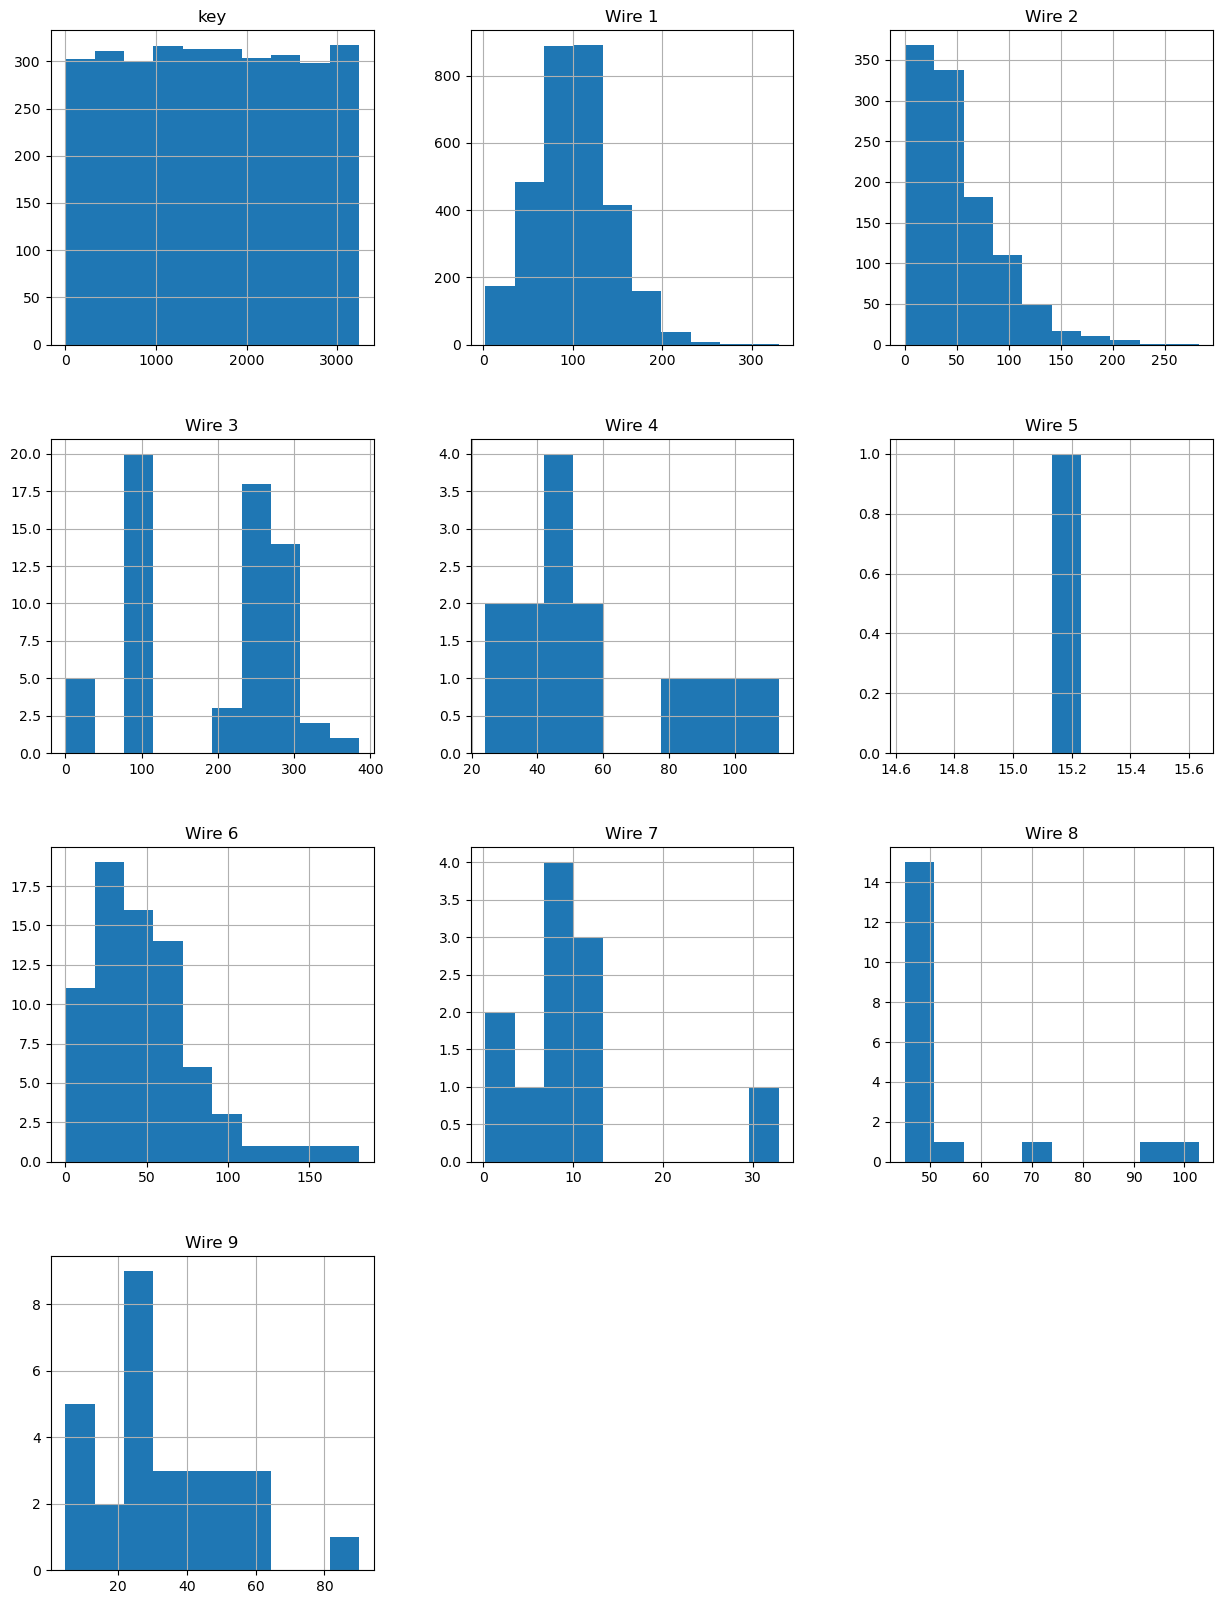

In [30]:
data_wire_new.info()
data_wire_new.hist(figsize=(15, 20))

In [31]:
data_wire_new.head()

,key,Wire 1,Wire 2,Wire 3,Wire 4,Wire 5,Wire 6,Wire 7,Wire 8,Wire 9
0,1,60.059998,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,96.052315,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,3,91.160157,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,4,89.063515,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,5,89.238236,9.11456,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [32]:
data_wire_new.describe()

,key,Wire 1,Wire 2,Wire 3,Wire 4,Wire 5,Wire 6,Wire 7,Wire 8,Wire 9
count,3081.000000,3055.000000,1079.000000,63.000000,14.000000,1.000,73.000000,11.000000,19.000000,29.000000
mean,1623.426485,100.895853,50.577323,189.482681,57.442842,15.132,48.016974,10.039007,53.625193,34.155752
std,932.996726,42.012518,39.320216,99.513444,28.824667,NaN,33.919845,8.610584,16.881728,19.931616
min,1.000000,1.918800,0.030160,0.144144,24.148801,15.132,0.034320,0.234208,45.076721,4.622800
25%,823.000000,72.115684,20.193680,95.135044,40.807002,15.132,25.053600,6.762756,46.094879,22.058401
50%,1619.000000,100.158234,40.142956,235.194977,45.234282,15.132,42.076324,9.017009,46.279999,30.066399
75%,2434.000000,126.060483,70.227558,276.252014,76.124619,15.132,64.212723,11.886057,48.089603,43.862003
max,3241.000000,330.314424,282.780152,385.008668,113.231044,15.132,180.454575,32.847674,102.762401,90.053604


In [33]:
data_wire_new.isna().sum()

key          0
Wire 1      26
Wire 2    2002
Wire 3    3018
Wire 4    3067
Wire 5    3080
Wire 6    3008
Wire 7    3070
Wire 8    3062
Wire 9    3052
dtype: int64

In [34]:
data_wire_new.duplicated().sum()

0

### Данные о проволочных материалах (время) (data_wire_time_new)

In [35]:
data_wire_time_new.info()
#data_wire_time_new.hist()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3081 entries, 0 to 3080
Data columns (total 10 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   key     3081 non-null   int64 
 1   Wire 1  3055 non-null   object
 2   Wire 2  1079 non-null   object
 3   Wire 3  63 non-null     object
 4   Wire 4  14 non-null     object
 5   Wire 5  1 non-null      object
 6   Wire 6  73 non-null     object
 7   Wire 7  11 non-null     object
 8   Wire 8  19 non-null     object
 9   Wire 9  29 non-null     object
dtypes: int64(1), object(9)
memory usage: 240.8+ KB


In [36]:
data_wire_time_new.head()

,key,Wire 1,Wire 2,Wire 3,Wire 4,Wire 5,Wire 6,Wire 7,Wire 8,Wire 9
0,1,2019-05-03 11:06:19,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,2019-05-03 11:36:50,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,3,2019-05-03 12:11:46,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,4,2019-05-03 12:43:22,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,5,2019-05-03 13:20:44,2019-05-03 13:15:34,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [37]:
data_wire_time_new.describe()

,key
count,3081.000000
mean,1623.426485
std,932.996726
min,1.000000
25%,823.000000
50%,1619.000000
75%,2434.000000
max,3241.000000


In [38]:
data_wire_time_new.isna().sum()

key          0
Wire 1      26
Wire 2    2002
Wire 3    3018
Wire 4    3067
Wire 5    3080
Wire 6    3008
Wire 7    3070
Wire 8    3062
Wire 9    3052
dtype: int64

In [39]:
data_wire_time_new.duplicated().sum()

0

## Вывод по исследовательскому анализу данных

1. Датафрейм **данных об электродах**  содержит 14876 строк с типом int64, object, float64; и 5 колонок: key, Начало нагрева дугой, Конец нагрева дуго, Активная мощность, Реактивная мощност. Присутствует аномалия в минимальном значении реактивной мощности. Там показывает -715, что в прниципе невозможно. Пропусков и дубликатов нет. 

2. Датафрейм **данных по подаче сыпучих материалов (объем)** содержит 3129 записей с типом int64  и float64, присутсвует 16 колонок: key, Bulk 1-Bulk 15. В данном датасете огромное количество пропусков и из-за этого очень трудно делать заключителньый анализ о данных по подаче сыпучих. Дубликатов нет. 

3. Датафрейм **данных о подаче сыпучих материалов (время)** содержит 3129 записей с типом int64  и object, присутсвует 16 колонок: key, Bulk 1-Bulk 15. Большое количество пропусков, нет дубликатов. Тип даты и времени нужно будет менять на datetime

4. Датафрейм **данных о продувке сплава газом** содержит 3239 записей с типом int64  и float64, присутствует всего 2 колонки: key и Газ 1. Нет дубликатов и нет пропусков. Возможно, судя по графику "Газ 1" есть выброс. 

5. Датафрейм **результатов измерения температуры** содержит 18092 записей с типом int64, float64 и object, есть 3 колонки: key, Время замера и Температура. Пропуски присутствуют только в колонке "Температура". Время нужно будет перевести в datetime. По графику, похоже, присутствует выброс в температуре

6. Датафрейм **данных о проволочных материалах (объем)**  содержит 3081 записей с типом int64  и float64, есть  10 колонок: key и Wire 1- 9. Нет дубликатов, но есть пропуски. Есть выбросы, пока по графику сильно заметно в Wire3, 4, 5,8 и 9

7. Датафрейм **данных о проволочных материалах (время)** содержит 3081 записей с типом int64  и object, есть  10 колонок: key и Wire 1- 9. Большое количество прпоусков. Нет дубликатов. Время нужно будет переводить в datetime.


**Итог**

Столбцы нужно будет переименовывать т.к. какие-то на русском, а какие-то на английском языке. Нужно будет менять формат даты на datetime. Скорее всего, где-то по итогу придется менять с десятичных чисел формат на целые. Большое количество пропусков. Их причины могут быть разные: ошибка в заполнении данных, отсутсвие необходимости или важности заполнить данные поля. 

### План действий

1 Пункт:
- [x]  Провести исследовательский анализ данных
- [x] Написать итоговый вывод

2 Пункт:
- [x] Перевести все время в нужный формат
- [x] Удалить ключ  с отрицательными значениями в электродах (перед удаление агрегировать данные)
- [x] Заполнить пропуски нулями в данных об объеме сыпучих и проволочных материалах
- [x] Нужно исследовать температуру ниже 1500 и удалить такие записи из датафрейма
- [x] КЛюч с одинаковым замером температуры удалить 
- [x] Разделить данные на обучающую и тестовую
- [x] Обработать выбросы
- [x] Объединить таблицы по ключу
- [x] СДелать корреляцию данных в виде тепловой карты

3 Пунтк:
- [ ] Обучить не менее 2-х моделей с кросс-валидацией
- [ ] Подбирать  в моделях не менее 2-х гиперпараметров 
- [ ] Выбрать лучшую модель по best_score
- [ ] Тест модели
- [ ] Расчитать метрику R2
    

### Вопросы

1. Тут скорее про Юпитер. ПОпыталась установить расширения хотябы для вывода содержания. Но ничего не вышло. Не подскажите, как вывести содержание? Что  установить? Или теперь можно будет делать здесь в самом практикуме т.к. загрузила ужде совю тетрадь. После загрузки появилось содержание) 

Пока вопросов по проекту нет. 

## 2 часть проекта

### Предобработка данных 

<div class="pirk">
Поменяем формат времени</div><i class="fa fa-lightbulb-o "></i>

In [40]:
data_arc_new['Начало нагрева дугой'] = pd.to_datetime(data_arc_new['Начало нагрева дугой'] )
data_arc_new['Конец нагрева дугой'] = pd.to_datetime(data_arc_new['Конец нагрева дугой'] )

In [41]:
#data_arc_new.info()

In [42]:
data_bulk_time_new['Bulk 1'] = pd.to_datetime(data_bulk_time_new['Bulk 1'])
data_bulk_time_new['Bulk 2'] = pd.to_datetime(data_bulk_time_new['Bulk 2'])
data_bulk_time_new['Bulk 3'] = pd.to_datetime(data_bulk_time_new['Bulk 3'])
data_bulk_time_new['Bulk 4'] = pd.to_datetime(data_bulk_time_new['Bulk 4'])
data_bulk_time_new['Bulk 5'] = pd.to_datetime(data_bulk_time_new['Bulk 5'])
data_bulk_time_new['Bulk 6'] = pd.to_datetime(data_bulk_time_new['Bulk 6'])
data_bulk_time_new['Bulk 7'] = pd.to_datetime(data_bulk_time_new['Bulk 7'])
data_bulk_time_new['Bulk 8'] = pd.to_datetime(data_bulk_time_new['Bulk 8'])
data_bulk_time_new['Bulk 9'] = pd.to_datetime(data_bulk_time_new['Bulk 9'])
data_bulk_time_new['Bulk 10'] = pd.to_datetime(data_bulk_time_new['Bulk 10'])
data_bulk_time_new['Bulk 11'] = pd.to_datetime(data_bulk_time_new['Bulk 11'])
data_bulk_time_new['Bulk 12'] = pd.to_datetime(data_bulk_time_new['Bulk 12'])
data_bulk_time_new['Bulk 13'] = pd.to_datetime(data_bulk_time_new['Bulk 13'])
data_bulk_time_new['Bulk 14'] = pd.to_datetime(data_bulk_time_new['Bulk 14'])
data_bulk_time_new['Bulk 15'] = pd.to_datetime(data_bulk_time_new['Bulk 15'])

In [43]:
#data_bulk_time_new.info()

In [44]:
data_temp_new['Время замера'] = pd.to_datetime(data_temp_new['Время замера'])

In [45]:
#data_temp_new.info()

In [46]:
data_wire_time_new['Wire 1'] = pd.to_datetime(data_wire_time_new['Wire 1'])
data_wire_time_new['Wire 2'] = pd.to_datetime(data_wire_time_new['Wire 2'])
data_wire_time_new['Wire 3'] = pd.to_datetime(data_wire_time_new['Wire 3'])
data_wire_time_new['Wire 4'] = pd.to_datetime(data_wire_time_new['Wire 4'])
data_wire_time_new['Wire 5'] = pd.to_datetime(data_wire_time_new['Wire 5'])
data_wire_time_new['Wire 6'] = pd.to_datetime(data_wire_time_new['Wire 6'])
data_wire_time_new['Wire 7'] = pd.to_datetime(data_wire_time_new['Wire 7'])
data_wire_time_new['Wire 8'] = pd.to_datetime(data_wire_time_new['Wire 8'])
data_wire_time_new['Wire 9'] = pd.to_datetime(data_wire_time_new['Wire 9'])

In [47]:
#data_wire_time_new.info()

<div class="pirk">
Теперь заполним пропуски нулями</div><i class="fa fa-lightbulb-o "></i>

In [48]:
data_bulk_new= data_bulk_new.fillna(0)
#data_bulk_new.isna().sum()

In [49]:
data_bulk_time_new=data_bulk_time_new.fillna(0)
#data_bulk_time_new.isna().sum()

In [50]:
data_wire_new=data_wire_new.fillna(0)
#data_wire_new.isna().sum()

In [51]:
data_wire_time_new=data_wire_time_new.fillna(0)
#data_wire_time_new.isna().sum()

<div class="pirk">
Теперь удалим выбросы в электродах </div><i class="fa fa-lightbulb-o "></i>

In [52]:
data_arc_new = data_arc_new[data_arc_new['Реактивная мощность'] > 0]
#data_arc_new.describe()

Посмотрим, как изменился график после удаления выброса

<AxesSubplot:>

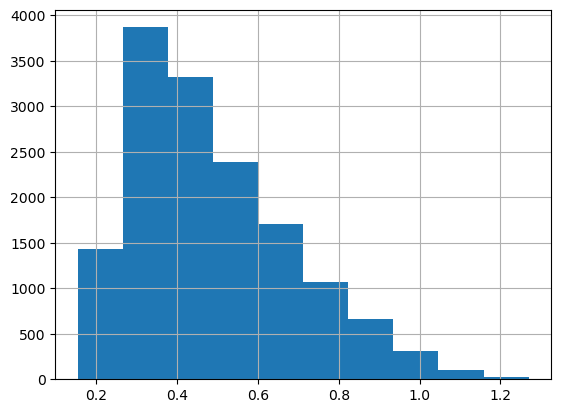

In [53]:
data_arc_new['Реактивная мощность'].hist()

Теперь в графике реактивной мощности есть корректные данные. График чем-то похож на график активной мощности

<span class="pirk">Займемся температурой</span>

Удалим  данные с низкой температурой (ниже 1500)

In [54]:
data_temp_new.shape

(18092, 3)

In [55]:
data_temp_new = data_temp_new[data_temp_new['Температура'] >= 1500]
data_temp_new.shape

(14660, 3)

Теперь найдем ключи, где только один замер температуры и удалим их

In [56]:
pivot_table = data_temp_new.pivot_table(index='key', values='Время замера', aggfunc='count')
pivot_table

,Время замера
key,
1,6
2,5
3,6
4,5
5,5
...,...
3237,1
3238,1
3239,1


In [57]:
one_key = pivot_table[pivot_table['Время замера'] == 1].index
one_key

Int64Index([ 195,  279, 2500, 2501, 2502, 2503, 2504, 2505, 2506, 2507,
            ...
            3232, 3233, 3234, 3235, 3236, 3237, 3238, 3239, 3240, 3241],
           dtype='int64', name='key', length=740)

In [58]:
data_temp_key= data_temp_new[~data_temp_new['key'].isin(one_key)]

#проверка удаления
#pivot_table1 = data_temp_key.pivot_table(index='key', values='Время замера', aggfunc='count')
#pivot_table1

ПО условию нашим <span class="mark">target</span> является последний замер температуры по всей партии. Создадим табилцу, где определим начало  и конец замера

In [59]:
data_temp = data_temp_key.groupby(by = 'key', as_index = False).agg(['first', 'last'])
data_temp.head()

Время замера                     Температура        
                  first                last       first    last
key                                                            
1   2019-05-03 11:02:04 2019-05-03 11:30:38      1571.0  1613.0
2   2019-05-03 11:34:04 2019-05-03 11:55:09      1581.0  1602.0
3   2019-05-03 12:06:44 2019-05-03 12:35:57      1596.0  1599.0
4   2019-05-03 12:39:27 2019-05-03 12:59:47      1601.0  1625.0
5   2019-05-03 13:11:03 2019-05-03 13:36:39      1576.0  1602.0

In [60]:
#data_temp=data_temp_key.pivot_table(index='key', aggfunc=['min','max'])
#ddata_temp=data_temp.reset_index()
data_temp.columns=['Время замера','Последний замер','Температура в начале', 'Температура в конце']
data_temp.head()

,Время замера,Последний замер,Температура в начале,Температура в конце
key,,,,
1,2019-05-03 11:02:04,2019-05-03 11:30:38,1571.0,1613.0
2,2019-05-03 11:34:04,2019-05-03 11:55:09,1581.0,1602.0
3,2019-05-03 12:06:44,2019-05-03 12:35:57,1596.0,1599.0
4,2019-05-03 12:39:27,2019-05-03 12:59:47,1601.0,1625.0
5,2019-05-03 13:11:03,2019-05-03 13:36:39,1576.0,1602.0


In [61]:
#data_temp.info()

<AxesSubplot:>

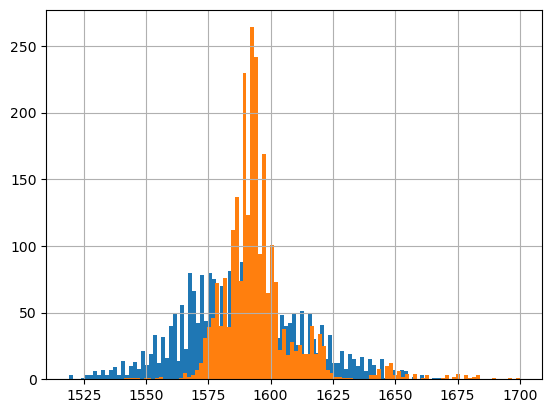

In [62]:
# Посмотрим на график температур чтобы увидеть есть ли выбросы
data_temp["Температура в начале"].hist(bins = 100)
data_temp["Температура в конце"].hist(bins = 100)

Выглядит, в принципе логично, только есть небольшие выброси после 1650. Температура плавления стали начинается на 1500

<AxesSubplot:>

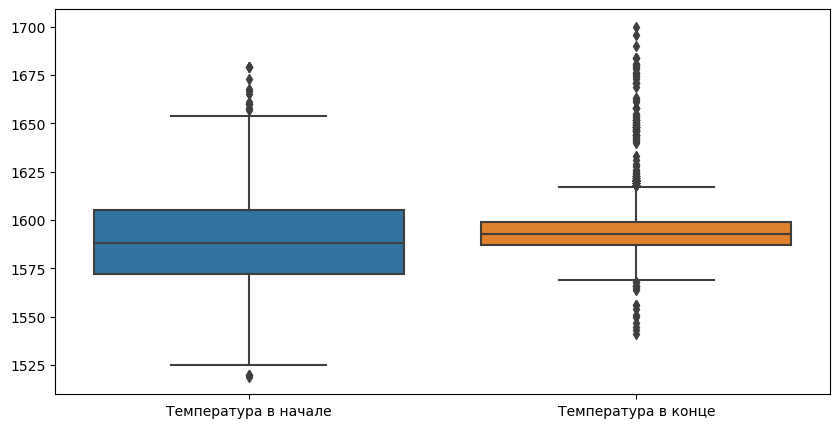

In [63]:
plt.figure(figsize=(10, 5))
sns.boxplot(data=data_temp)

In [64]:
data_temp = data_temp[(1530 < data_temp['Температура в начале']) & (data_temp['Температура в начале'] < 1620)]
data_temp = data_temp[data_temp['Температура в конце'] < 1640]
data_temp.shape

(2151, 4)

In [65]:
data_temp['Время замера'] = pd.to_datetime(data_temp['Время замера'])
data_temp['Последний замер'] = pd.to_datetime(data_temp['Последний замер'])

<span class="pirk">Теперь займемся выбросами по датафрейму с газом</span>

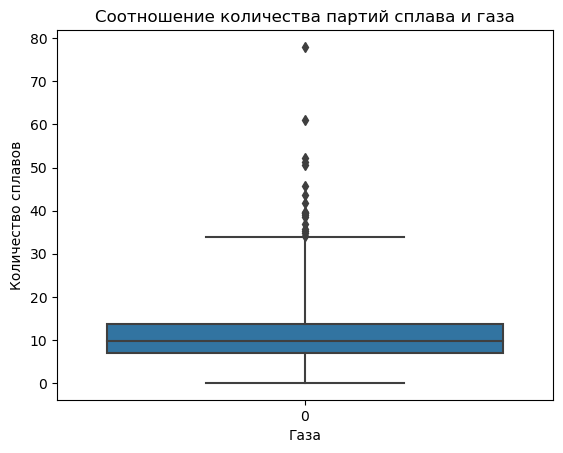

In [66]:
#лучше всего увидим выбросы через ящик с усами
box_plot = sns.boxplot(data_gas_new['Газ 1'],whis=3)
plt.title('Соотношение количества партий сплава и газа')
plt.xlabel('Газа')
plt.ylabel('Количество сплавов');

Можно заметить, что есть выбросы  где-то после 33. Нужно удалить

In [67]:
data_gas = data_gas_new[data_gas_new['Газ 1']<33]

<div class="pirk">
Посмотрим на аномалии d сыпучих материалах и  проволочных материалах</div><i class="fa fa-lightbulb-o "></i>

<AxesSubplot:>

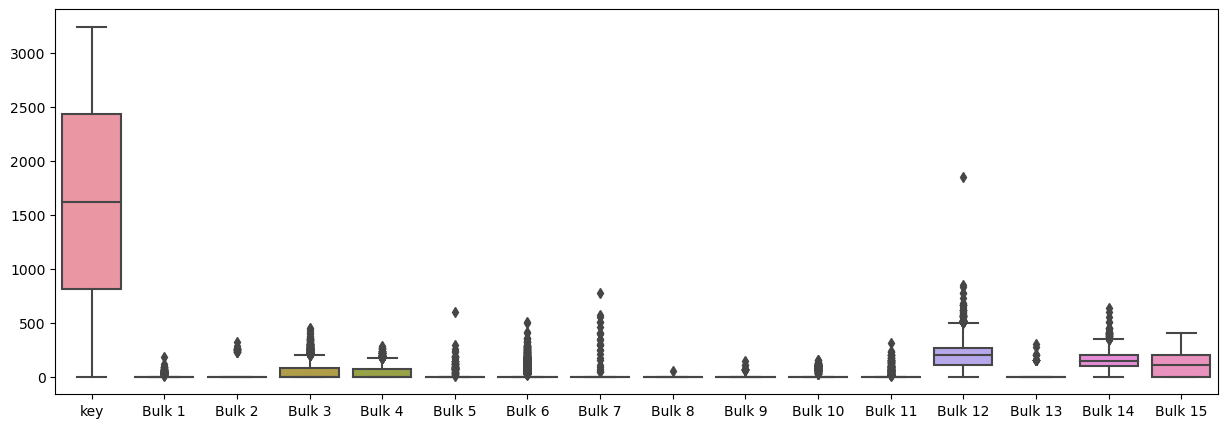

In [68]:
plt.figure(figsize=(15, 5))
sns.boxplot(data=data_bulk_new)

<AxesSubplot:>

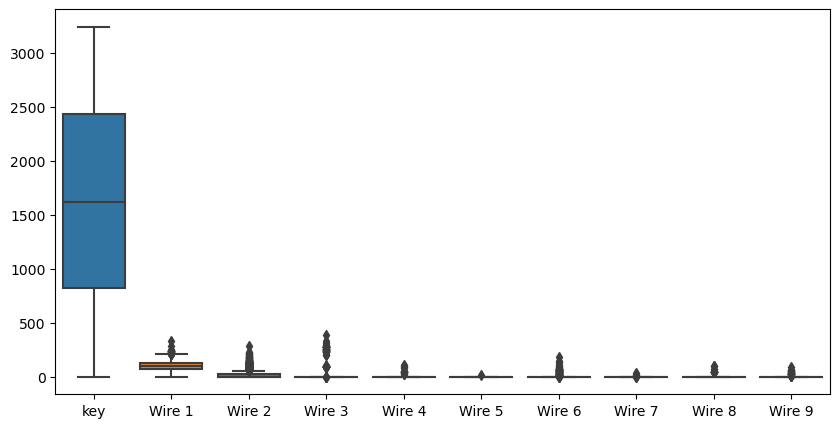

In [69]:
plt.figure(figsize=(10, 5))
sns.boxplot(data=data_wire_new)

Выбросов по сути куча, нго удалив их все мы ничего и вовсе не оставим. Можно удалить Wire 5 т.к. по ощущениям там и вовсе ничего нет

In [70]:
data_wire=data_wire_new.drop(['Wire 5'], axis= 1)
data_wire.shape

(3081, 9)

###  Объединение таблиц

Сначала переименуем все столбцы, привидем их к единому виду 

In [71]:
data_arc_new.columns= ['key', 'start_time', 'end_time', 'active_power', 'reactive_power']
data_gas.columns= ['key', 'gas_1']
data_temp.columns= ['time_temp', 'time_last_temp', 'temp_start', 'temp_end']
data_bulk_new.columns= ['key', 'bulk_1', 'bulk_2', 'bulk_3', 'bulk_4', 'bulk_5', 'bulk_6', 'bulk_7', 'bulk_8', 'bulk_9', 'bulk_10', 'bulk_11', 'bulk_12', 'bulk_13', 'bulk_14', 'bulk_15']
data_bulk_time_new.columns=  ['key', 'bulk_1_t', 'bulk_2_t', 'bulk_3_t', 'bulk_4_t', 'bulk_5_t', 'bulk_6_t', 'bulk_7_t', 'bulk_8_t', 'bulk_9_t', 'bulk_10_t', 'bulk_11_t', 'bulk_12_t', 'bulk_13_t', 'bulk_14_t', 'bulk_15_t']
data_wire.columns= ['key', 'wire_1', 'wire_2', 'wire_3', 'wire_4', 'wire_6', 'wire_7', 'wire_8', 'wire_9']
data_wire_time_new.columns= ['key', 'wire_1_t', 'wire_2_t', 'wire_3_t', 'wire_4_t', 'wire_5_t', 'wire_6_t', 'wire_7_t', 'wire_8_t', 'wire_9_t']

In [72]:
data_temp.head(5)

,time_temp,time_last_temp,temp_start,temp_end
key,,,,
1,2019-05-03 11:02:04,2019-05-03 11:30:38,1571.0,1613.0
2,2019-05-03 11:34:04,2019-05-03 11:55:09,1581.0,1602.0
3,2019-05-03 12:06:44,2019-05-03 12:35:57,1596.0,1599.0
4,2019-05-03 12:39:27,2019-05-03 12:59:47,1601.0,1625.0
5,2019-05-03 13:11:03,2019-05-03 13:36:39,1576.0,1602.0


In [73]:
dataframes = [data_arc_new, data_gas, data_temp, data_bulk_new, data_wire]
df = pd.concat(dataframes, join='inner', axis=1)
df.tail()

,key,start_time,end_time,active_power,reactive_power,key,gas_1,time_temp,time_last_temp,temp_start,...,bulk_15,key,wire_1,wire_2,wire_3,wire_4,wire_6,wire_7,wire_8,wire_9
2495,541,2019-05-24 00:24:03,2019-05-24 00:28:35,1.107216,0.756300,2498,14.953657,2019-08-10 11:27:47,2019-08-10 11:50:47,1570.0,...,232.0,2622,55.167839,30.340960,0.0,0.0,0.0,0.0,0.0,0.0
2496,541,2019-05-24 00:31:50,2019-05-24 00:34:57,0.468234,0.394713,2499,11.336151,2019-08-10 11:56:48,2019-08-10 12:25:13,1554.0,...,224.0,2623,56.085121,52.146641,0.0,0.0,0.0,0.0,0.0,0.0
2497,541,2019-05-24 00:45:15,2019-05-24 00:48:06,0.619386,0.452829,2500,9.990718,2019-08-10 12:37:26,2019-08-10 12:53:28,1571.0,...,226.0,2630,30.008158,0.000000,0.0,0.0,0.0,0.0,0.0,0.0
2498,541,2019-05-24 01:02:37,2019-05-24 01:04:15,0.594044,0.414143,2501,13.828957,2019-08-10 12:58:11,2019-08-10 13:23:31,1591.0,...,0.0,2631,117.324486,0.000000,0.0,0.0,0.0,0.0,0.0,0.0
2499,542,2019-05-24 01:10:58,2019-05-24 01:14:44,0.800939,0.621456,2502,13.890142,2019-08-10 13:33:21,2019-08-10 13:58:58,1569.0,...,108.0,2632,90.111840,45.119358,0.0,0.0,0.0,0.0,0.0,0.0


In [74]:
df.shape

(2134, 36)

In [75]:
df = df.drop('key',axis=1)

In [76]:
df.shape

(2134, 32)

<span class="girk">Условие, что  после объединение не должно оставаться ключей с номером более 2500 выполнено, key удалили</span>

По условию также у нас также вышло менее 2332 ключа

In [77]:
df.describe()

,active_power,reactive_power,gas_1,temp_start,temp_end,bulk_1,bulk_2,bulk_3,bulk_4,bulk_5,...,bulk_14,bulk_15,wire_1,wire_2,wire_3,wire_4,wire_6,wire_7,wire_8,wire_9
count,2134.000000,2134.000000,2134.000000,2134.000000,2134.000000,2134.000000,2134.000000,2134.000000,2134.000000,2134.000000,...,2134.000000,2134.000000,2134.000000,2134.000000,2134.000000,2134.000000,2134.000000,2134.000000,2134.000000,2134.000000
mean,0.663887,0.486994,10.804888,1583.331303,1592.786785,3.317245,1.801312,45.396439,36.656045,2.285380,...,153.357545,118.179007,101.746404,18.296533,4.143881,0.330874,1.230679,0.051747,0.273526,0.395846
std,0.257026,0.195291,5.638569,19.166000,10.570993,12.391342,21.504802,73.816598,58.193840,17.741875,...,82.360459,85.634571,43.945874,34.879651,30.910704,4.927422,9.459684,0.929867,3.992222,4.207615
min,0.228852,0.153777,0.008399,1531.000000,1545.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.468184,0.337804,7.063312,1570.000000,1587.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,105.000000,0.000000,72.159357,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.600696,0.442468,9.856023,1584.000000,1592.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,149.000000,107.000000,100.354800,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,0.827921,0.606038,13.694046,1598.000000,1598.000000,0.000000,0.000000,76.000000,77.000000,0.000000,...,204.000000,204.000000,127.639976,24.150619,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,1.437648,1.213404,32.796358,1619.000000,1626.000000,185.000000,325.000000,454.000000,281.000000,293.000000,...,636.000000,405.000000,330.314424,282.780152,385.008668,113.231044,180.454575,32.847674,102.762401,90.053604


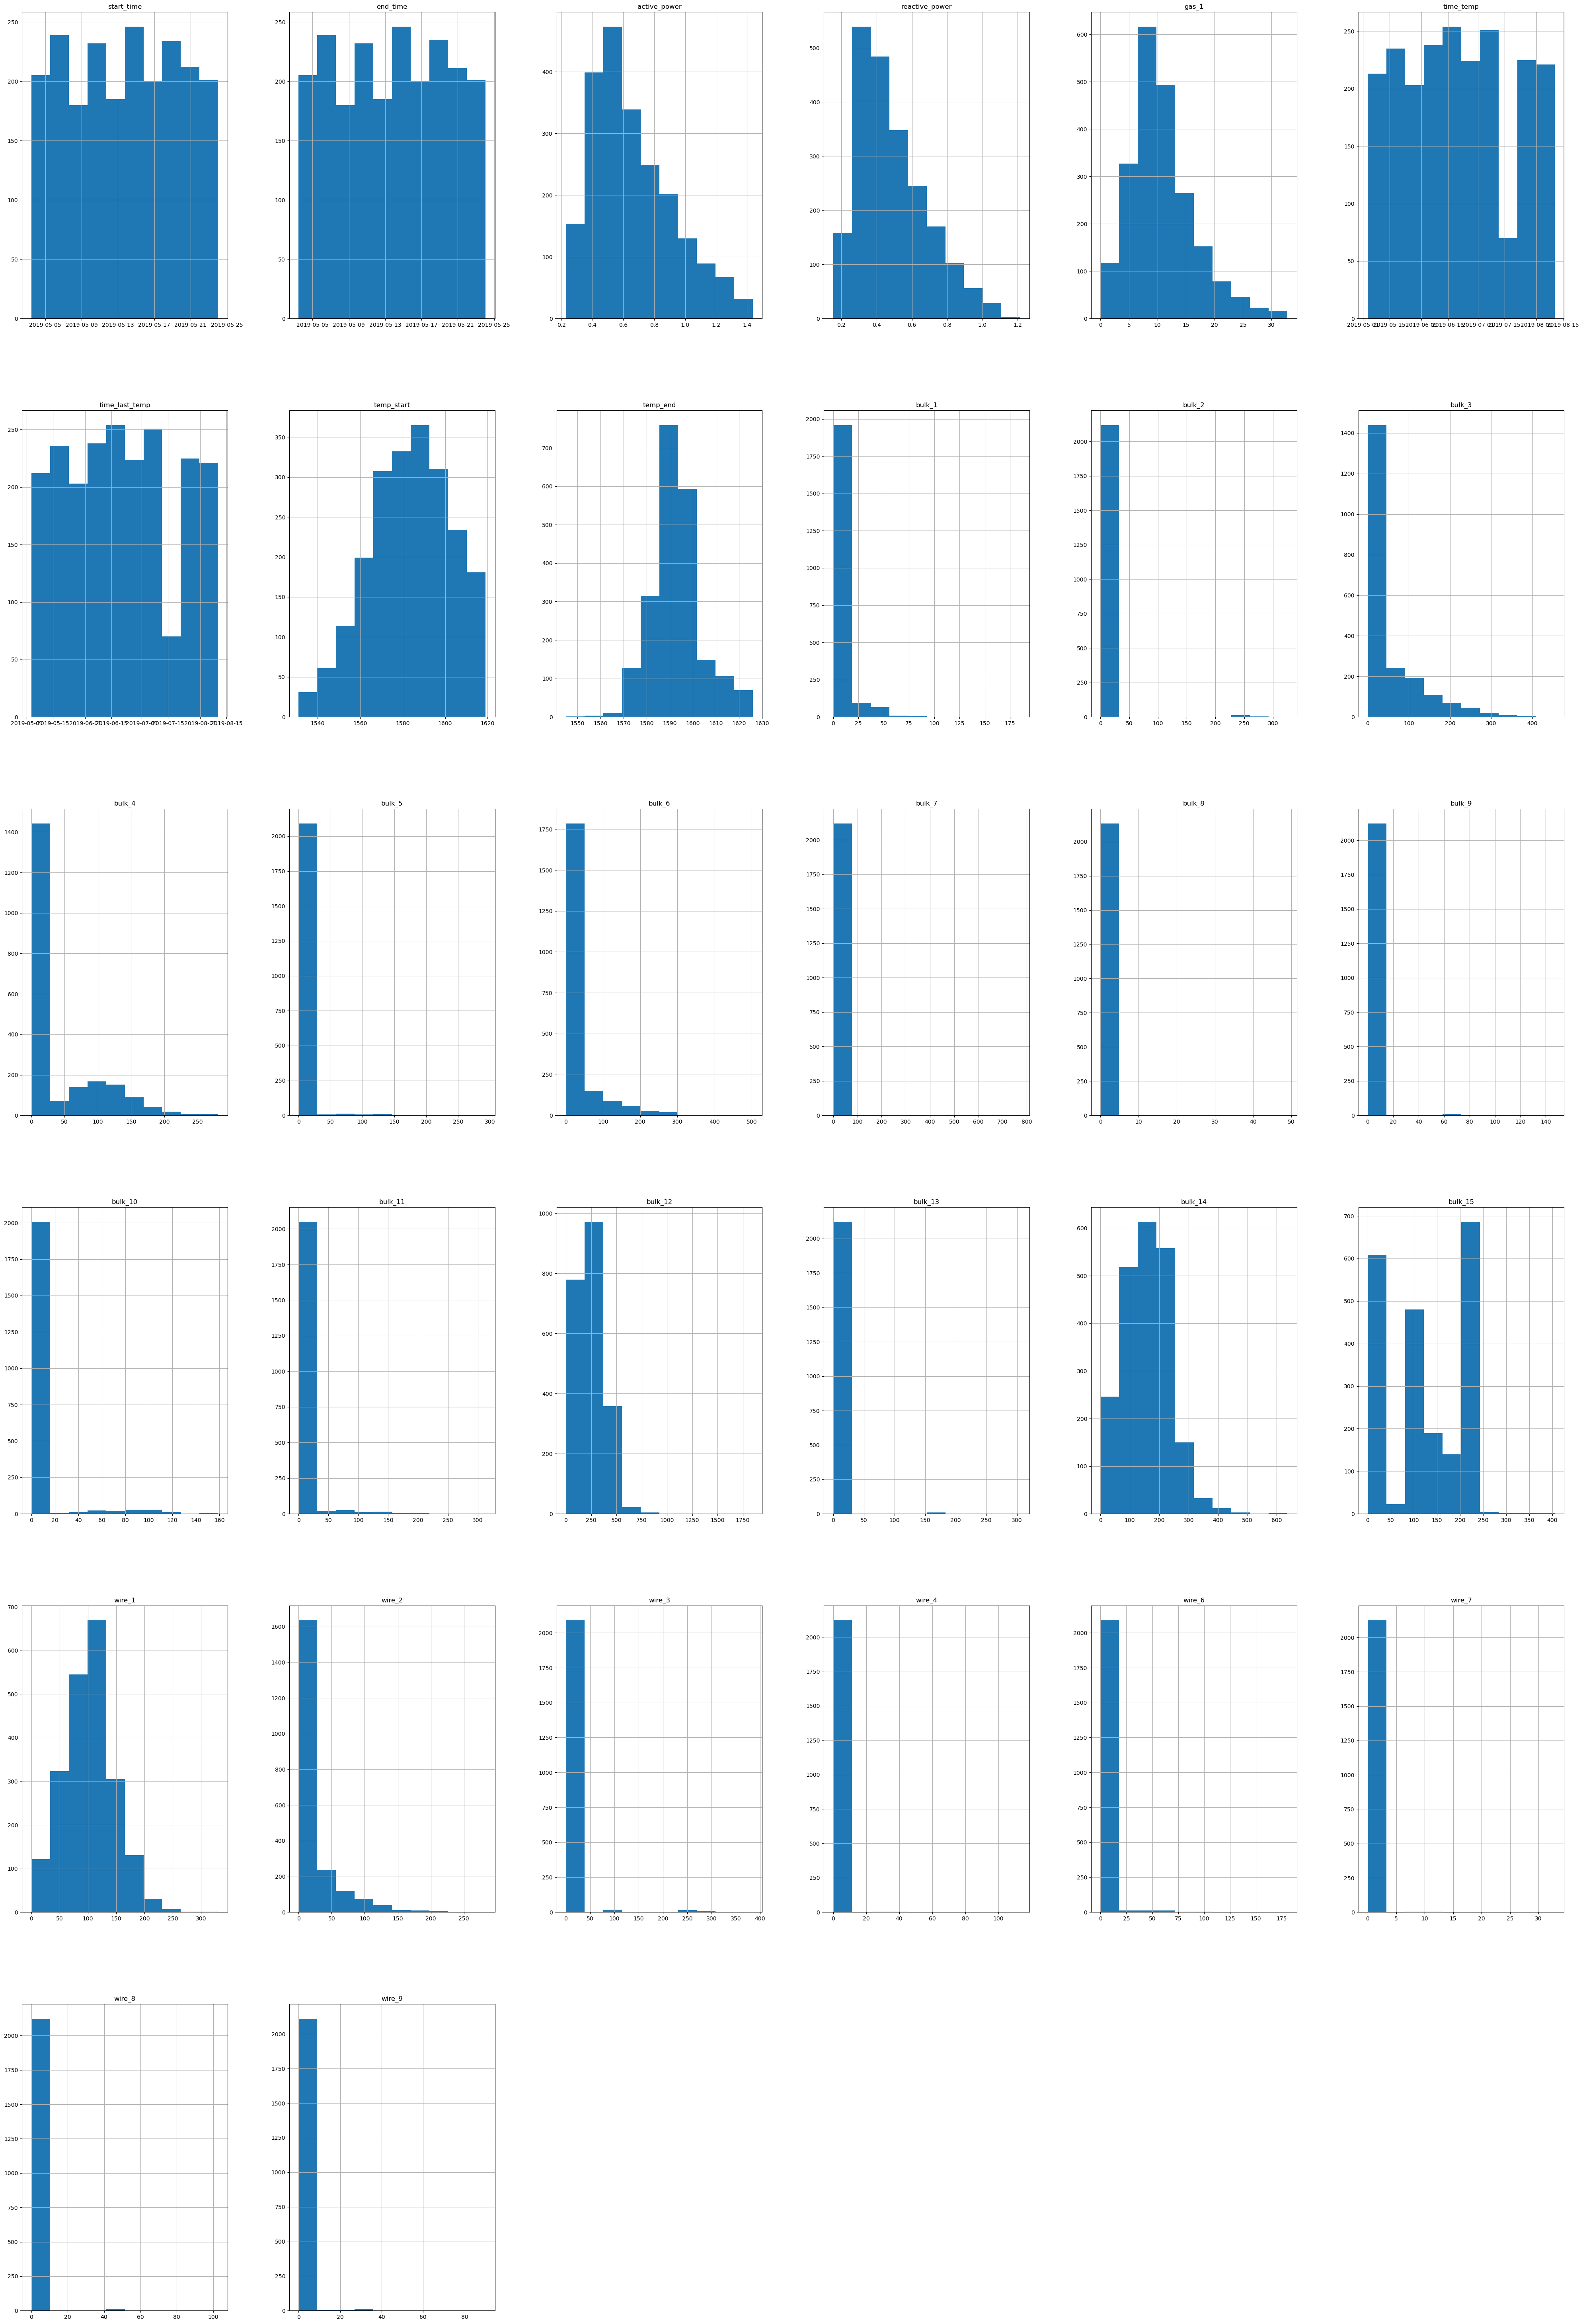

In [78]:
df.hist(figsize=(50, 75));

Т.к. теперь все признаки обхеденены в однц табилцу, то можно вызвать матрицу корреляцию всех признаков

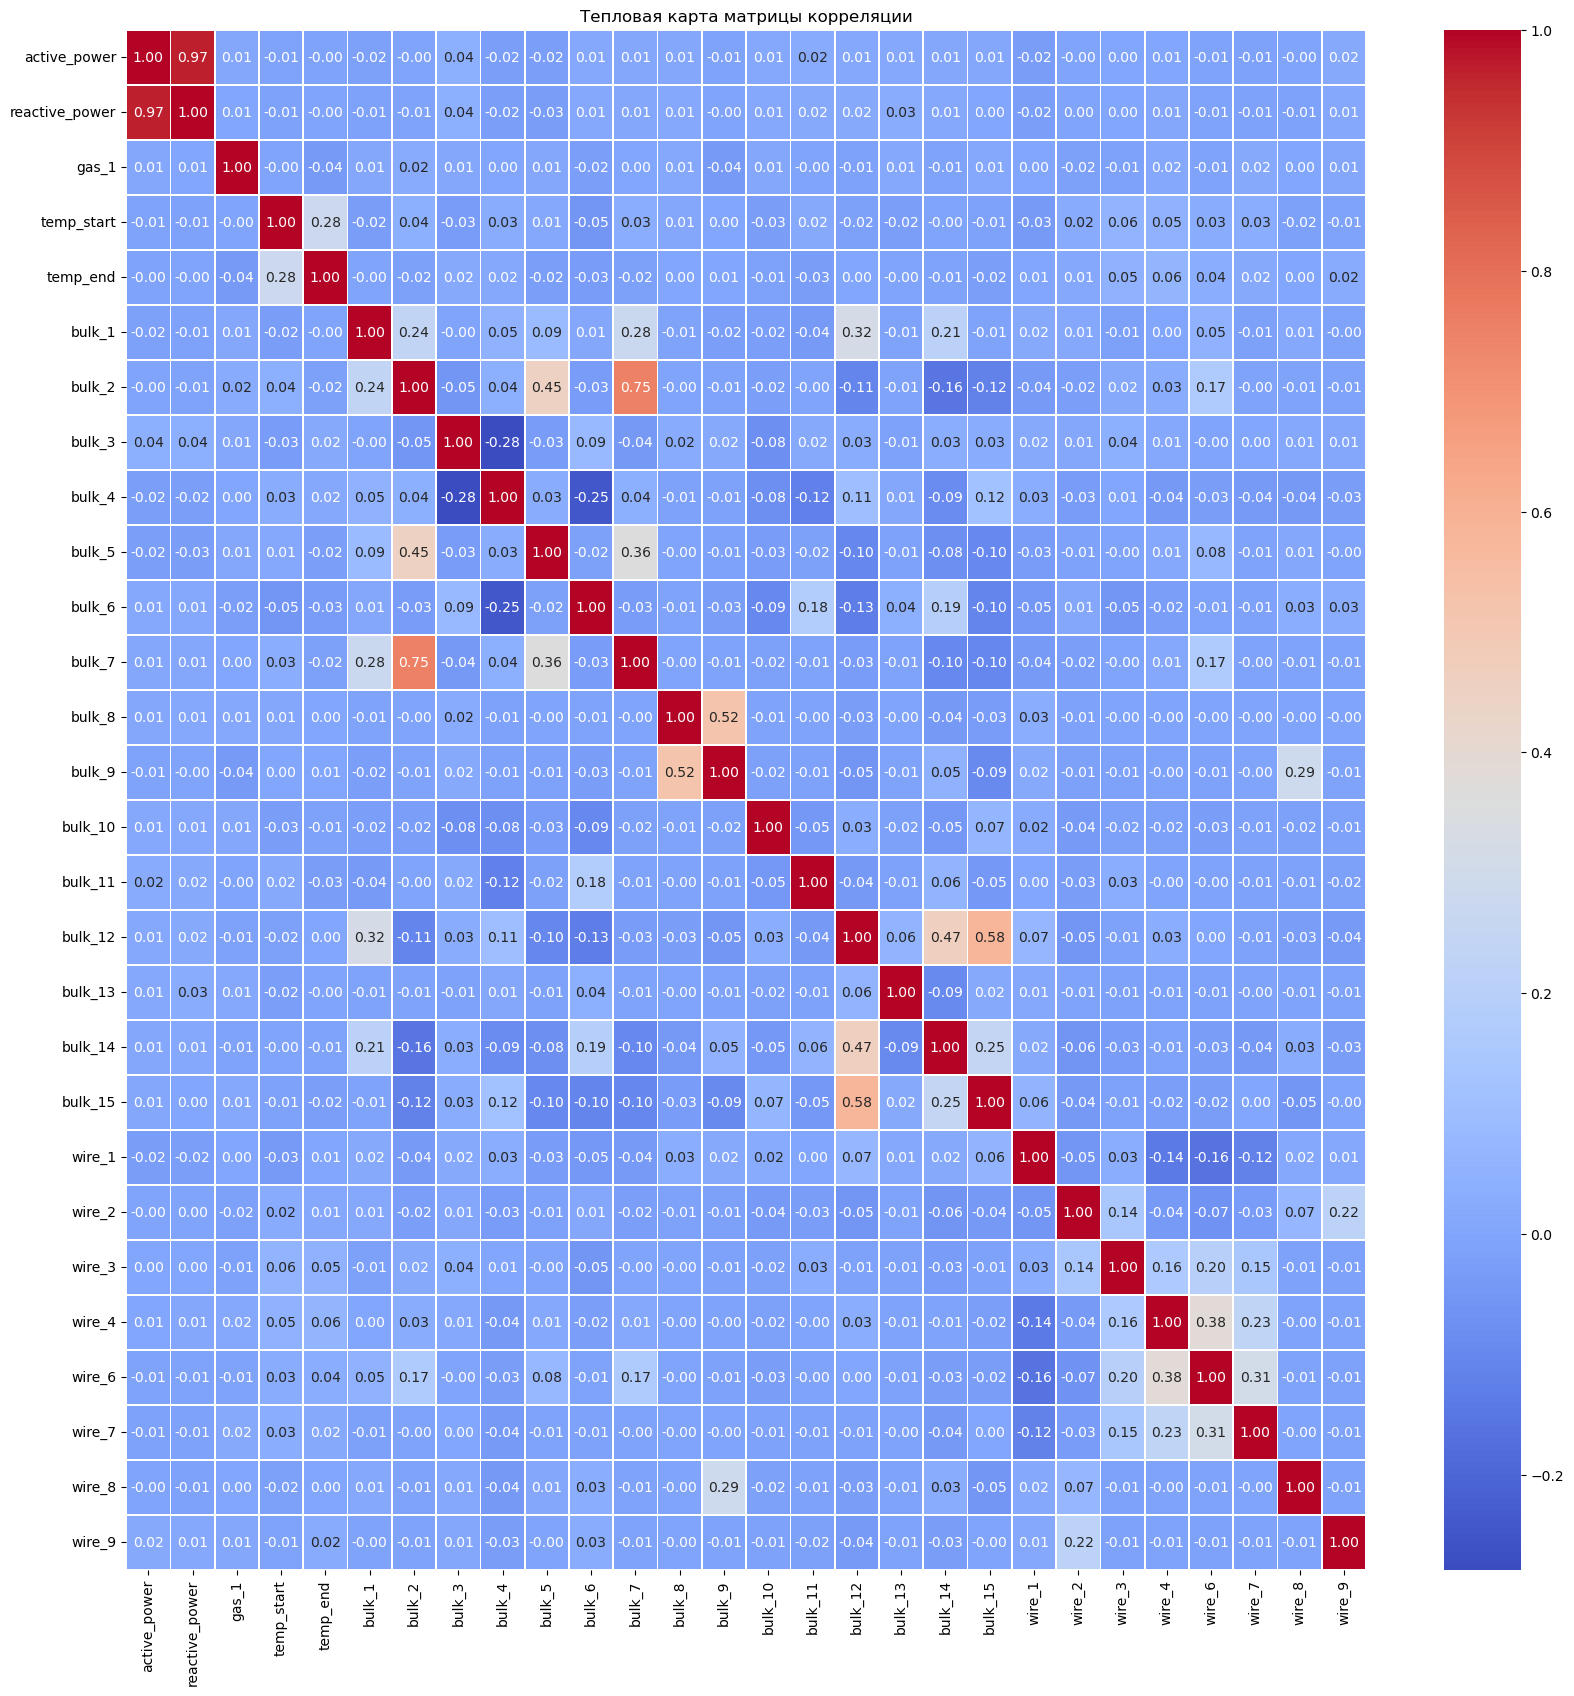

In [79]:
correlation_matrix = df.corr()
plt.figure(figsize=(20, 20))
sns.heatmap(correlation_matrix, cmap='coolwarm', annot=True, fmt=".2f", linewidths=0.5)
plt.title('Тепловая карта матрицы корреляции')
plt.show()

Как видно по матрици есть превышаюшщие значения корреляции, которые нужно минимизировтаь. Есть сильная корреляция между bulk 2 и  bulk 7, удалим первое. Уже по слабее корреляция есть у bulk 12 и 15, также удалим первое

In [80]:
df=df.drop(['bulk_2', 'bulk_12'], axis= 1)
df.shape

(2134, 30)

Также можно удалить реактивную мощность  и wire 6 т.к. коррелирует с wire 4

In [81]:
df=df.drop(['reactive_power', 'wire_6'], axis= 1)
df.shape

(2134, 28)

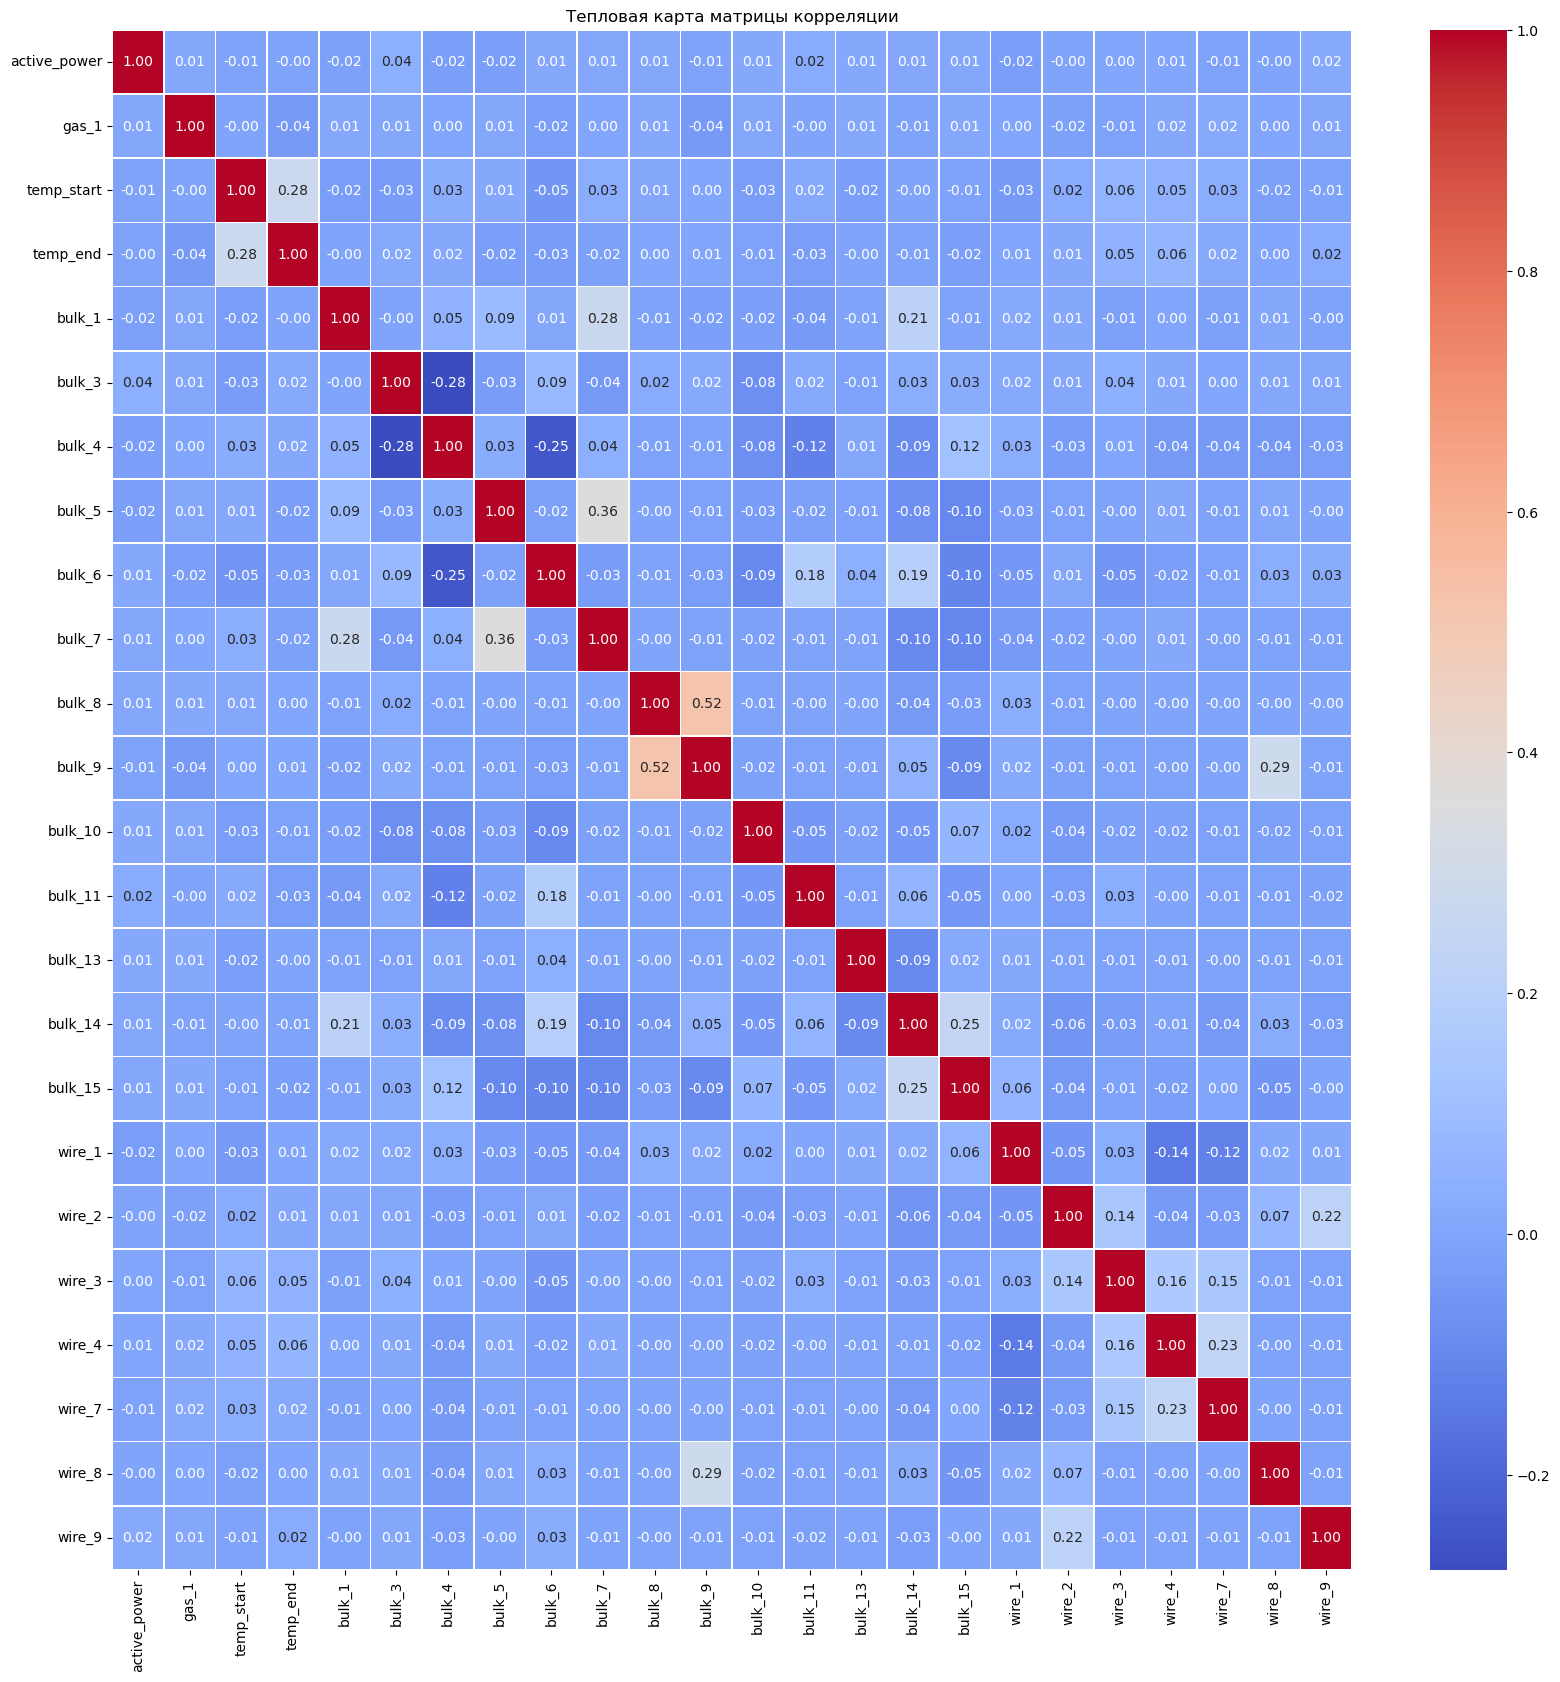

In [82]:
#еще раз посомтрим на матрицу, но уже с удаленными признакми
correlation_matrix = df.corr()
plt.figure(figsize=(20, 20))
sns.heatmap(correlation_matrix, cmap='coolwarm', annot=True, fmt=".2f", linewidths=0.5)
plt.title('Тепловая карта матрицы корреляции')
plt.show()

Высокая корреляция также осталась у начала температуры с температурой в конце, и  у bulk_8 и 9, и 7 и 5, wire 7 и 4. Также стоит удалить

In [83]:
df=df.drop(['bulk_9', 'bulk_7', 'wire_4'], axis= 1)
df.shape

(2134, 25)

### Разделение на выборки 

In [84]:
#определим признаки
features = df.drop('temp_end', axis=1)
target = df['temp_end']

# Разделим данные на обучающую и тестовую выборки:
features_train, features_test, target_train, target_test = train_test_split(
    features, target, test_size=0.2, random_state=random_state)

In [85]:
print(features_train.shape)
print(target_train.shape)

(1707, 24)
(1707,)


In [86]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 2134 entries, 1 to 2499
Data columns (total 25 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   start_time      2134 non-null   datetime64[ns]
 1   end_time        2134 non-null   datetime64[ns]
 2   active_power    2134 non-null   float64       
 3   gas_1           2134 non-null   float64       
 4   time_temp       2134 non-null   datetime64[ns]
 5   time_last_temp  2134 non-null   datetime64[ns]
 6   temp_start      2134 non-null   float64       
 7   temp_end        2134 non-null   float64       
 8   bulk_1          2134 non-null   float64       
 9   bulk_3          2134 non-null   float64       
 10  bulk_4          2134 non-null   float64       
 11  bulk_5          2134 non-null   float64       
 12  bulk_6          2134 non-null   float64       
 13  bulk_8          2134 non-null   float64       
 14  bulk_10         2134 non-null   float64       
 15  bulk

<div class="girk">
Условию соответсвует: обучающая выборка должна быть не менее 1700 строк</div><i class="fa fa-lightbulb-o "></i>

In [87]:
features_train.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 1707 entries, 475 to 2316
Data columns (total 24 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   start_time      1707 non-null   datetime64[ns]
 1   end_time        1707 non-null   datetime64[ns]
 2   active_power    1707 non-null   float64       
 3   gas_1           1707 non-null   float64       
 4   time_temp       1707 non-null   datetime64[ns]
 5   time_last_temp  1707 non-null   datetime64[ns]
 6   temp_start      1707 non-null   float64       
 7   bulk_1          1707 non-null   float64       
 8   bulk_3          1707 non-null   float64       
 9   bulk_4          1707 non-null   float64       
 10  bulk_5          1707 non-null   float64       
 11  bulk_6          1707 non-null   float64       
 12  bulk_8          1707 non-null   float64       
 13  bulk_10         1707 non-null   float64       
 14  bulk_11         1707 non-null   float64       
 15  bu


**Масштабируем наши признаки**

In [88]:
#выделим столбцы с числами, чтобы не было ошибок из-за дат
numeric_columns = ['active_power', 'gas_1','temp_start', 'bulk_1', 'bulk_3', 'bulk_4', 'bulk_5',
                   'bulk_6', 'bulk_8', 'bulk_10', 'bulk_11', 'bulk_13', 'bulk_14',
                   'bulk_15', 'wire_1', 'wire_2', 'wire_3', 'wire_7', 'wire_8', 'wire_9']

# Создание объекта StandardScaler
scaler = StandardScaler()
scaler.fit(features_train[numeric_columns])
# Масштабирование числовых признаков
#features_train[numeric_columns] = scaler.fit_transform(features_train[numeric_columns])
features_train[numeric_columns] = scaler.transform(features_train[numeric_columns])
# Преобразуем массив NumPy обратно в DataFrame и добавим имена столбцов
scaled_features_df = pd.DataFrame(features_train[numeric_columns], columns=features_train.columns)

 <a id='section_id2'></a>
масштабирование на трейни

### Обучение модели 

#### Линейная регрессия

In [89]:
%%time

model_lr = LinearRegression()
lr_mae = (cross_val_score(model_lr, 
                             features_train[numeric_columns], 
                             target_train, 
                             cv=5, 
                             scoring='neg_mean_absolute_error').mean() * -1)
print('MAE на линейной регерссии =',  lr_mae)

MAE на линейной регерссии = 7.6222389229575285
CPU times: total: 93.8 ms
Wall time: 22.9 ms


In [90]:
#создадим таблицу, чтобы по итогу сравнить
index_table = 0
table = pd.DataFrame(columns=['модель','mse'])
index_table +=1
table.loc[index_table] = ['Linear Regression', lr_mae]

<div class="alert alert-success">
<h2> Комментарий ревьюера <a class="tocSkip"> </h2>

<b>Все отлично!👍:</b> 
        
Метрика выбрана верно - МАЕ)

#### Дерево решений 

In [91]:
%%time
model_tree = DecisionTreeRegressor(random_state=random_state)
param_grid={
    'max_depth': range(1, 26, 5)
}
gs_tree = GridSearchCV(model_tree, param_grid=param_grid, scoring='neg_mean_absolute_error', n_jobs=-1)
gs_tree.fit(features_train[numeric_columns], target_train)
print(f'Гиперпараметры лучшей модели: {gs_tree.best_params_}') 
print(f'Значение MAE: {-1 * gs_tree.best_score_}')

Гиперпараметры лучшей модели: {'max_depth': 1}
Значение MAE: 7.795936952379923
CPU times: total: 672 ms
Wall time: 3.04 s


In [92]:
index_table +=1
table.loc[index_table] = ['DecisionTree',\
                          -1 * gs_tree.best_score_]

#### LightGBM 

In [93]:
%%time
gbm = LGBMRegressor(boosting_type='gbdt', verbose=1, random_state=random_state)
gbm_params = {'learning_rate': np.logspace(-3, 0, 5), 'n_estimators': range(20, 61, 20), 'num_leaves': range(20, 41, 10)}
grid_gbm = GridSearchCV(gbm, gbm_params, cv=5, scoring='neg_mean_squared_error')
grid_gbm.fit(features_train[numeric_columns], target_train)
print(grid_gbm.best_params_)
grid_gbm.best_score_

[LightGBM] [Warning] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000100 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1638
[LightGBM] [Info] Number of data points in the train set: 1365, number of used features: 15
[LightGBM] [Info] Start training from score 1592.806593
[LightGBM] [Warning] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000194 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1639
[LightGBM] [Info] Number of data points in the train set: 1365, number of used features: 15
[LightGBM] [Info] Start training from score 1592.856410
[LightGBM] [Warning] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000131 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [I

-106.642446555478

In [94]:
%%time
model_gbm = grid_gbm.best_estimator_
MSE_gbm = (cross_val_score(model_gbm, 
                             features_train[numeric_columns], 
                             target_train, 
                             cv=5, 
                             scoring='neg_mean_squared_error').mean() * -1) ** 0.5
print('MSE LightGBM =', MSE_gbm)

[LightGBM] [Warning] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000207 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1638
[LightGBM] [Info] Number of data points in the train set: 1365, number of used features: 15
[LightGBM] [Info] Start training from score 1592.806593
[LightGBM] [Warning] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000210 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1639
[LightGBM] [Info] Number of data points in the train set: 1365, number of used features: 15
[LightGBM] [Info] Start training from score 1592.856410
[LightGBM] [Warning] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000189 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1627
[LightGBM] [Info] Number of data points in the train set: 1366, number of used features: 15
[LightGBM] [Inf

In [95]:
index_table +=1
table.loc[index_table] = ['LightGBM',\
                          MSE_gbm]

#### CatBoost 

In [96]:
%%time

model_cat = CatBoostRegressor(verbose=False, random_state=random_state)
cat_mse= (cross_val_score(model_cat , 
                             features_train[numeric_columns], 
                             target_train, 
                             cv=5, 
                             scoring='neg_mean_absolute_error').mean() * -1)
print('MAE  =', cat_mse)


MAE  = 8.110609561850431
CPU times: total: 1min 2s
Wall time: 8.14 s


In [97]:
index_table +=1
table.loc[index_table] = [' CatBoost',\
                          cat_mse]

#### Лучшая модель 

In [98]:
table

,модель,mse
1,Linear Regression,7.622239
2,DecisionTree,7.795937
3,LightGBM,10.326783
4,CatBoost,8.110610


Самая лучшая модель по результата MSE у нас линецная регрессия, ее результата ~7.86. Ее тестировать и будем

### Тестирование модели 

In [99]:
#выделим столбцы с числами, чтобы не было ошибок из-за дат
numeric_columns_test = ['active_power', 'gas_1', 'temp_start','bulk_1', 'bulk_3', 'bulk_4', 'bulk_5',
                   'bulk_6', 'bulk_8', 'bulk_10', 'bulk_11', 'bulk_13', 'bulk_14',
                   'bulk_15', 'wire_1', 'wire_2', 'wire_3', 'wire_7', 'wire_8', 'wire_9']

# Создание объекта StandardScaler
#scaler = StandardScaler()

# Масштабирование числовых признаков
#features_test[numeric_columns_test] = scaler.fit_transform(features_test[numeric_columns_test])
# Преобразуем массив NumPy обратно в DataFrame и добавим имена столбцов
#scaled_features_test = pd.DataFrame(features_test[numeric_columns_test], columns=features_test.columns)

In [100]:
features_test[numeric_columns_test] = scaler.transform(features_test[numeric_columns_test])

In [101]:
model_test = LinearRegression()
model_test.fit(features_train[numeric_columns], target_train)
predicted = model_test.predict(features_test[numeric_columns_test])
mse_t=mean_absolute_error(target_test, predicted)
mse_t

7.626815628004074